# Analysis of data for the Essential FFPE Panel

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import cohen_kappa_score
from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

from tqdm import trange

### BatchDetect module imports

Import project-specific helpers from the `batchdetect` package:

- `load_thal_cross_lot_covs` and related loaders for Thalassemia data.
- `HeavyMixture` and `parametric_bootstrap_lrt` for mixture modeling and
  parametric bootstrap-based likelihood ratio tests.
- Correlation-based clustering utilities:
  `cluster_hierarchical_corr`, `cluster_spectral_corr`,
  `cluster_pca_kmeans_corr`.
- Correlation preprocessing helpers: `normalize_mat` and `get_correlations`.

These functions implement the main batch-detection and clustering methods used
throughout the analysis.


In [2]:
from batchdetect.loader import load_br283_cross_lot_covs
from batchdetect.mixture import HeavyMixture,parametric_bootstrap_lrt

In [3]:
df_thal_likelihoods = pd.read_csv('../likelihoods_br283.csv')
snames = df_thal_likelihoods['Sample Name'].values
likelihoods = df_thal_likelihoods['Likelihood'].values
y_hat = df_thal_likelihoods['Label'].values

### Load  count data and metadata

Load the cross-lot coverage
matrix and associated metadata:

- `counts_thal`: amplicon-level coverage counts per sample.
- `y_thal`: sample labels from the loader (if provided).
- `sample_id`: sample identifiers.
- `features`: amplicon/feature annotations.

These raw counts are used for correlation-based clustering and neighborhood
analysis.


In [4]:
counts_thal,y_thal,sample_id,features,_ = load_br283_cross_lot_covs()
counts_thal = counts_thal[:-1]
y_thal = y_thal[:-1]
sample_id = sample_id[:-1]

In [5]:
index_homozygous_del = [12,13,14]
counts_thal_new = np.delete(counts_thal, index_homozygous_del, axis=0)
likelihoods_new = np.delete(likelihoods, index_homozygous_del)
y_new = np.delete(y_hat, index_homozygous_del)
snames_new = np.delete(snames,index_homozygous_del)

In [6]:
def null_factory():
    return HeavyMixture(
                n_components=1,
                component_distribution='laplace',
                n_init=3,
                max_iter=1000,
            )   

def alt_factory():
            return HeavyMixture(
                n_components=2,
                component_distribution='laplace',
                n_init=3,
                max_iter=1000,
            )   

In [7]:
n_rep = 3
rng = np.random.default_rng(2021)
res_list = []
for i in trange(n_rep):
    idx = rng.choice(len(y_new),replace=True,size=len(y_new))
    X_sub = likelihoods_new[idx]
    y_sub = y_new[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list.append(res)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:13<00:00,  4.56s/it]


In [16]:
res = parametric_bootstrap_lrt(
            likelihoods_new,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )

In [17]:
res

{'statistic': 13.46690291731204,
 'p_value': np.float64(0.03792415169660679),
 'lr_bootstrap': array([ 1.00574829e+00,  1.57137229e+00,  6.71637127e+00,  2.29409293e+00,
         2.34521525e-01,  5.58957264e+00,  1.56341790e+01,  2.23210236e+00,
         2.16127463e+00,  2.39425295e+00,  1.17834124e+00,  1.35878613e+01,
         5.00937613e+00,  5.28769720e+00,  2.20343944e+00,  4.85415486e+00,
         6.86605539e+00,  2.30528226e+00,  9.21415462e+00,  1.39888086e-01,
         2.14377663e+00,  4.91178947e-02,  1.96302932e+00,  1.24709691e+00,
         1.55907752e+00,  3.58046203e+00,  4.51664310e-01,  6.78455030e+00,
         7.02160757e+00,  3.24686467e+00,  4.98839338e+00,  3.39654651e+00,
         2.06044849e+00,  3.84033016e+00,  2.15201652e+00,  1.02073027e+01,
         7.70868033e+00,  2.30409096e+00,  2.99061227e+00,  1.77849679e+01,
         2.33555658e+00,  4.01886565e+00,  6.71140867e+00,  5.76917278e+00,
         6.57247669e-01, -2.35877359e-02,  8.66310775e+00,  4.56912306

In [8]:
print([res['p_value'] for res in res_list])

[np.float64(0.04790419161676647), np.float64(0.007984031936127744), np.float64(0.001996007984031936)]


In [9]:
like_pos = likelihoods_new[y_new==0]
like_pos

array([  -0.83648252,  -74.24453776,  -22.40349212,   19.77401804,
         73.65803564,   58.11057909, -115.042654  ,   58.014638  ])

In [10]:
snames_pos = snames_new[y_new==0]
snames_pos[like_pos< -100]

array(['QCvSMpBRCAFFPEgCNVd230615iM3-TV2-20ng-Rep1-21PB1431'],
      dtype=object)

In [11]:
snames_new[y_new==0]

array(['QCvSMpBRCAFFPEgCNVd230615iM3-BRCNV-1-20ng-Rep121PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-BRCNV-2-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-BRCNV-3-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-BRCNV-4-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-TV12-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-TV14-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-TV2-20ng-Rep1-21PB1431',
       'QCvSMpBRCAFFPEgCNVd230615iM3-TV3-20ng-Rep1-21PB1431'],
      dtype=object)

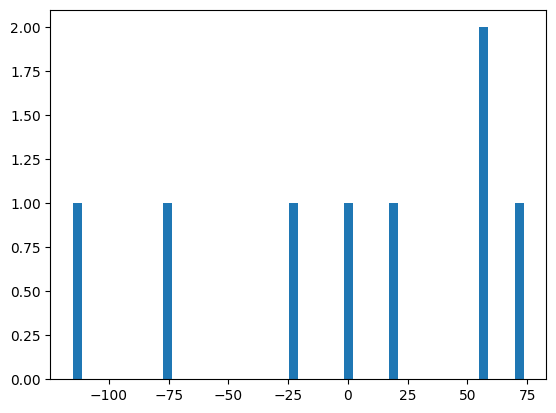

In [12]:
plt.hist(like_pos,50);

In [13]:
n_rep = 3
rng = np.random.default_rng(2021)
res_list_pos = []
for i in trange(n_rep):
    idx = rng.choice(len(like_pos),replace=True,size=len(like_pos))
    X_sub = like_pos[idx]
    res = parametric_bootstrap_lrt(
            X_sub,  
            null_model_factory=null_factory,
            alt_model_factory=alt_factory,
            n_bootstrap=500,
            random_state=i,
        )
    res_list_pos.append(res)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.67s/it]


In [14]:
print([res['p_value'] for res in res_list_pos])

[np.float64(0.001996007984031936), np.float64(0.001996007984031936), np.float64(0.001996007984031936)]


In [15]:
likelihoods_new[y_new==1]

array([ 81.43040809,  70.11569498, 106.8028401 , 137.5392671 ,
        91.85353954, 194.882045  , -49.08568846, 203.1850578 ,
       199.046932  , 214.5181388 , 148.8299456 , 116.4568554 ,
        56.35627356, 176.5138787 , 185.8627093 , 202.485593  ])